In [11]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from nsd_access import NSDAccess
from nsd_visuo_semantics.get_embeddings.word_lists import coco_categories_91


In [9]:
# 1. Initialize NSD Access
nsda = NSDAccess("../data/NSD")

# 2. Iterate exactly over the 73,000 NSD IDs to guarantee consistent ordering
num_nsd_images = 73000
nsd_ids = list(range(num_nsd_images))

# categories = nsda.read_image_coco_category(nsd_ids)

In [7]:
import json
import pickle

# with open("categories.json", "w") as f:
#     json.dump(categories, f)

with open("./input/categories.json", 'rb') as f:
    categories = json.load(f)

with open("./input/ms_coco_nsd_captions_test.pkl", 'rb') as f:
    captions_data = pickle.load(f)

['Six military planes that are flying in formation.', 'a couple of jets are flying in the sky', 'A sky view of six jet plans in the sky. ', 'a number of jets flying in the air near one another ', 'Six planes fly in formation in the blue sky.']
['airplane']


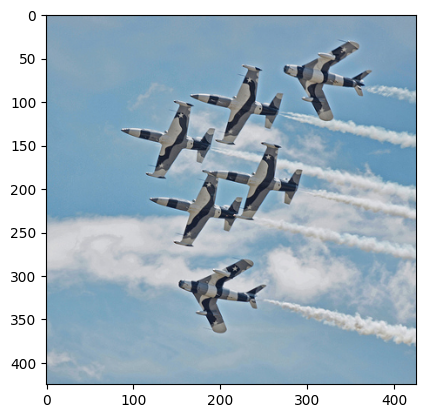

In [5]:
index = 70000
print(captions_data[index])
print(categories[index])
img = nsda.read_images([index])
plt.imshow(img[0])

In [ ]:
images = nsda.read_images(nsd_ids)

In [21]:

def sanity_check(categories, nsd_captions_path, embeddings_path, words_path, save_name):
    total_n_stims = len(categories)
    plot_n_imgs = 10
    step_size = total_n_stims // plot_n_imgs

    with open(nsd_captions_path, "rb") as fp:
        loaded_captions = pickle.load(fp)
    with open(words_path, "rb") as fp:  # Pickling
        loaded_words = pickle.load(fp)
    with open(embeddings_path, "rb") as fp:  # Pickling
        loaded_embeddings = pickle.load(fp)

    os.makedirs(os.path.dirname(save_name), exist_ok=True)
    for i in range(0, total_n_stims, step_size):
        plt.imshow(nsda.read_images([i])[0])
        plt.title(
            f"{loaded_captions[i][0]}\n"
            f"{loaded_words[i]}\n"
            f"Emb shape, min, max, mean: {loaded_embeddings[i].shape, loaded_embeddings[i].min(), loaded_embeddings[i].max(), loaded_embeddings[i].mean()}"
        )
        plt.savefig(f"{save_name}{i}.png")
        plt.close()

In [22]:
sanity_check(categories, "./input/ms_coco_nsd_captions_test.pkl", "./results/saved_embeddings/nsd_fasttext_VERBS_embeddings.pkl", "./results/saved_embeddings/nsd_verbs_per_image.pkl", "./results/sanity_checks/fasttext_verbs/")

In [9]:
# Replace spaces with hyphens in all categories
categories_hyphenated = [[cat.replace('fire hydrant', 'fireplug') for cat in cat_list] for cat_list in categories]
categories_hyphenated = [[cat.replace('fire hydrant', 'fireplug') for cat in cat_list] for cat_list in categories_hyphenated]
categories_hyphenated = [[cat.replace('street sign', 'signpost') for cat in cat_list] for cat_list in categories_hyphenated]
categories_hyphenated = [[cat.replace('parking meter', 'self-parking') for cat in cat_list] for cat_list in categories_hyphenated]
categories_hyphenated = [[cat.replace('sports ball', 'ball') for cat in cat_list] for cat_list in categories_hyphenated]
categories_hyphenated = [[cat.replace('potted plant', 'houseplant') for cat in cat_list] for cat_list in categories_hyphenated]
categories_hyphenated = [[cat.replace('hair drier', 'hairdryer') for cat in cat_list] for cat_list in categories_hyphenated]
categories_hyphenated = [[cat.replace('hair brush', 'hairbrush') for cat in cat_list] for cat_list in categories_hyphenated]
categories_hyphenated = [[cat.replace(' ', '-') for cat in cat_list] for cat_list in categories_hyphenated]

# Write to file
with open("./categories_hyphenated.pkl", "wb") as f:
    pickle.dump(categories_hyphenated, f)